In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read dataset
df = pd.read_csv("../data/processed/github_repositories_featured.csv")

# Display first 5 rows
df.head()

Matplotlib is building the font cache; this may take a moment.


,repository_name,full_name,owner,description,language,stars,forks,watchers,open_issues,size_kb,...,has_wiki,has_pages,archived,disabled,repository_age_days,days_since_last_update,star_fork_ratio,is_active,description_length,has_license
0,build-your-own-x,codecrafters-io/build-your-own-x,codecrafters-io,Master programming by recreating your favorite...,Markdown,521744,49367,521744,515,1100,...,False,False,False,False,2976,0,10.57,True,73,False
1,awesome,sindresorhus/awesome,sindresorhus,😎 Awesome lists about all kinds of interesting...,NaN,480790,35646,480790,88,1565,...,False,True,False,False,4374,0,13.49,True,53,True
2,freeCodeCamp,freeCodeCamp/freeCodeCamp,freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,TypeScript,450845,45334,450845,205,577580,...,False,False,False,False,4207,0,9.94,True,111,True
3,public-apis,public-apis/public-apis,public-apis,A collective list of free APIs,Python,446001,48948,446001,1480,6864,...,False,False,False,False,3755,0,9.11,True,30,True
4,free-programming-books,EbookFoundation/free-programming-books,EbookFoundation,:books: Freely available programming books,Python,391129,66468,391129,76,21499,...,False,True,False,False,4647,0,5.88,True,42,True


In [3]:
df.shape

(1000, 28)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   repository_name         1000 non-null   str    
 1   full_name               1000 non-null   str    
 2   owner                   1000 non-null   str    
 3   description             992 non-null    str    
 4   language                910 non-null    str    
 5   stars                   1000 non-null   int64  
 6   forks                   1000 non-null   int64  
 7   watchers                1000 non-null   int64  
 8   open_issues             1000 non-null   int64  
 9   size_kb                 1000 non-null   int64  
 10  default_branch          1000 non-null   str    
 11  created_at              1000 non-null   str    
 12  updated_at              1000 non-null   str    
 13  license                 916 non-null    str    
 14  topics                  845 non-null    str    
 15 

In [ ]:
df.describe() 

,stars,forks,watchers,open_issues,size_kb,repository_age_days,days_since_last_update,star_fork_ratio,description_length
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000
mean,64010.268000,9677.987000,64010.268000,861.573000,4.365428e+05,2816.912000,0.009000,12.175650,89.043000
std,50829.830802,11675.093801,50829.830802,2462.228911,1.994928e+06,1625.518679,0.094488,44.553566,191.773482
min,32055.000000,29.000000,32055.000000,0.000000,5.000000e+00,20.000000,0.000000,0.520000,0.000000
25%,37409.500000,3482.750000,37409.500000,59.750000,1.081700e+04,1302.750000,0.000000,5.527500,43.000000
50%,47272.000000,6170.500000,47272.000000,243.000000,5.965900e+04,2876.000000,0.000000,8.740000,68.000000
75%,69486.500000,10592.500000,69486.500000,710.250000,2.241460e+05,4126.000000,0.000000,13.245000,106.000000
max,521744.000000,109856.000000,521744.000000,37316.000000,4.354393e+07,6656.000000,1.000000,1392.370000,5835.000000


In [6]:
df.isnull().sum()

repository_name             0
full_name                   0
owner                       0
description                 8
language                   90
stars                       0
forks                       0
watchers                    0
open_issues                 0
size_kb                     0
default_branch              0
created_at                  0
updated_at                  0
license                    84
topics                    155
visibility                  0
has_issues                  0
has_projects                0
has_wiki                    0
has_pages                   0
archived                    0
disabled                    0
repository_age_days         0
days_since_last_update      0
star_fork_ratio             0
is_active                   0
description_length          0
has_license                 0
dtype: int64

In [ ]:
#summary :
# 90 values null hain language mein 
#8 in description
#license 84
#topics mein 155

In [7]:
df.duplicated().sum()


np.int64(0)

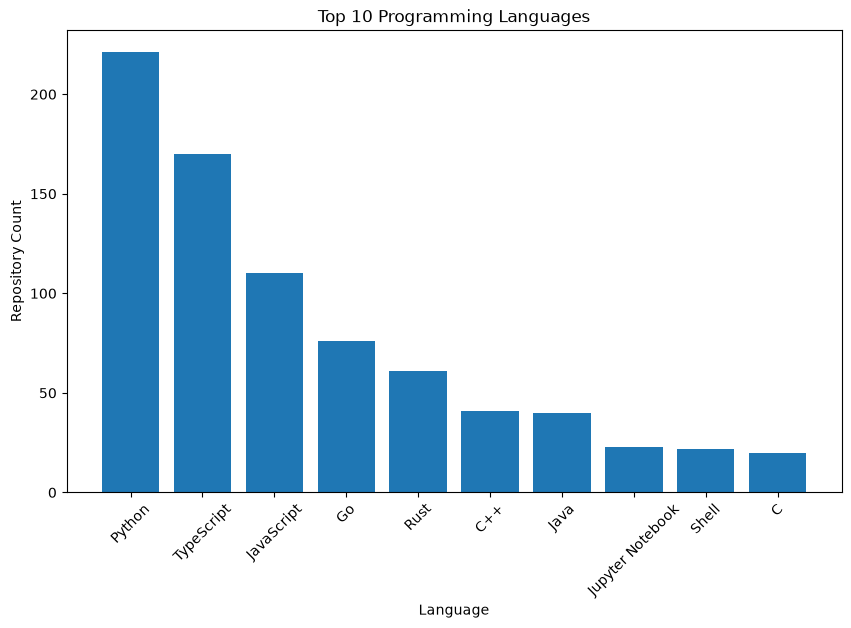

In [8]:
#top 10 programming languages !! in the dataset 
language_counts = df["language"].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(language_counts.index, language_counts.values)
plt.title("Top 10 Programming Languages")
plt.xlabel("Language")
plt.ylabel("Repository Count")
plt.xticks(rotation=45)
plt.show()

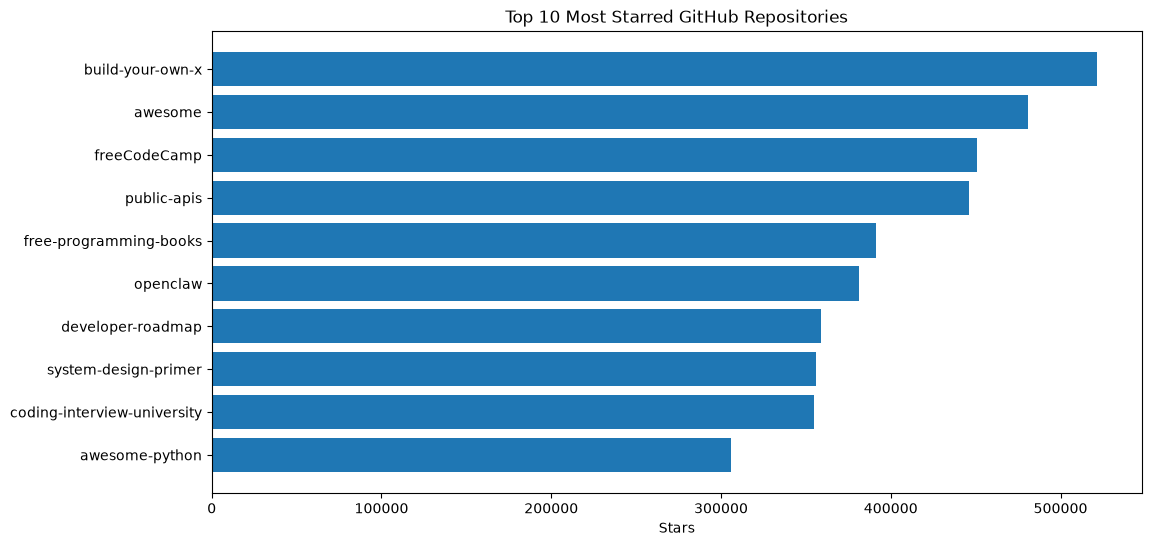

In [ ]:
#top 10 most starred repositories!


top10 = df.sort_values("stars", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top10["repository_name"], top10["stars"])
plt.title("Top 10 Most Starred GitHub Repositories")
plt.xlabel("Stars")
plt.gca().invert_yaxis()
plt.show()

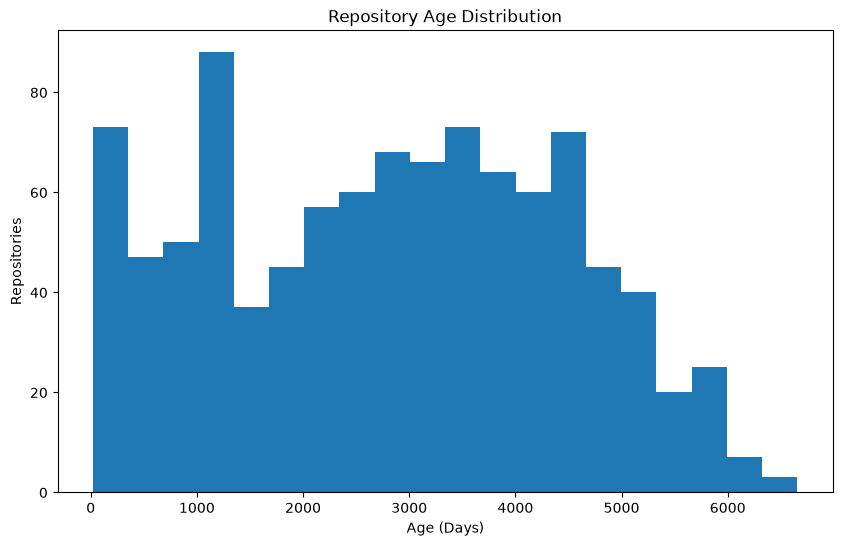

In [ ]:
plt.figure(figsize=(10,6)) #repositories age distribution

plt.hist(df["repository_age_days"], bins=20)
plt.title("Repository Age Distribution")
plt.xlabel("Age (Days)")
plt.ylabel("Repositories")
plt.show()

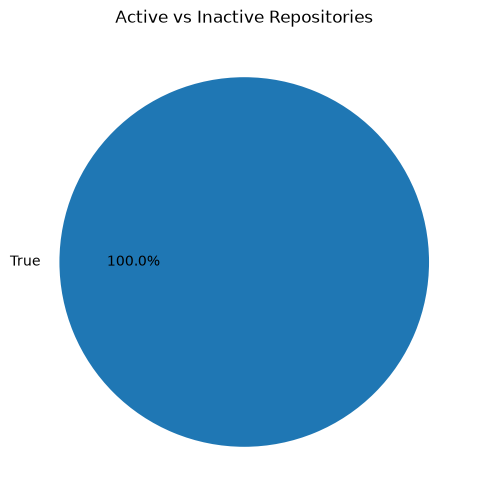

In [11]:
active = df["is_active"].value_counts() #active vs inactive graph

plt.figure(figsize=(6,6))
plt.pie(
    active.values,
    labels=active.index,
    autopct="%1.1f%%"
)
plt.title("Active vs Inactive Repositories")
plt.show()

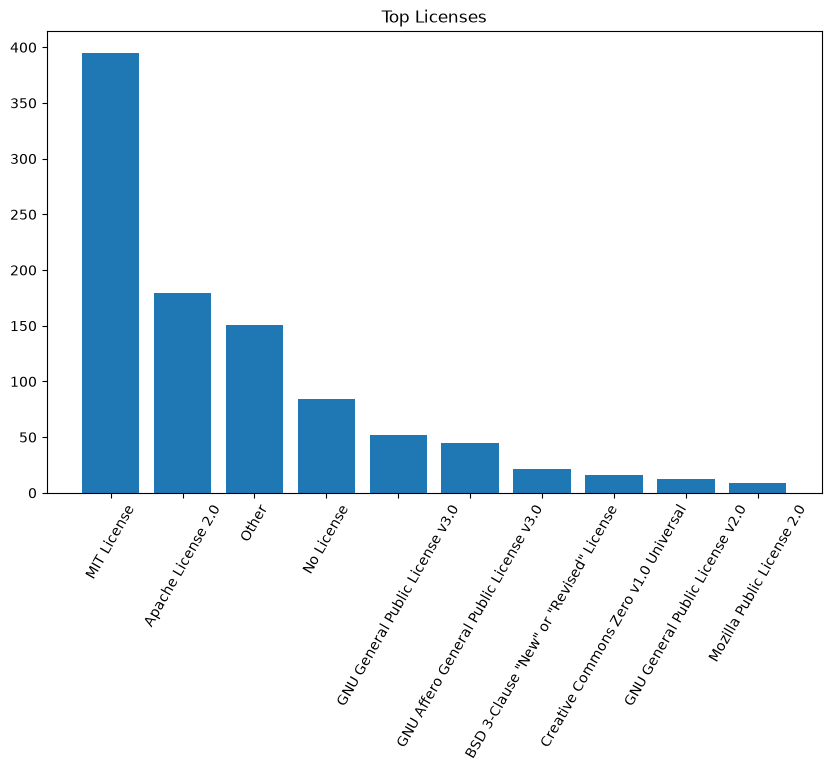

In [12]:
license_counts = df["license"].fillna("No License").value_counts().head(10)
#license distribution
plt.figure(figsize=(10,6))
plt.bar(license_counts.index, license_counts.values)
plt.title("Top Licenses")
plt.xticks(rotation=60)
plt.show()

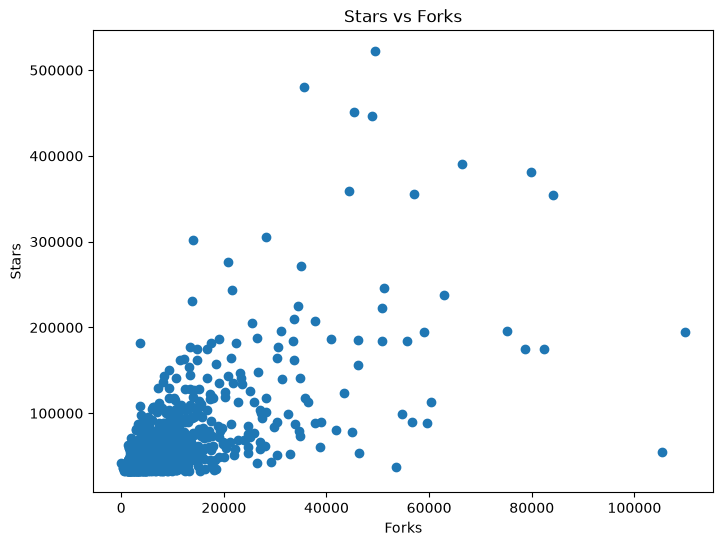

In [13]:
plt.figure(figsize=(8,6))#stars vs folk relationship
plt.scatter(df["forks"], df["stars"])
plt.title("Stars vs Forks")
plt.xlabel("Forks")
plt.ylabel("Stars")
plt.show()

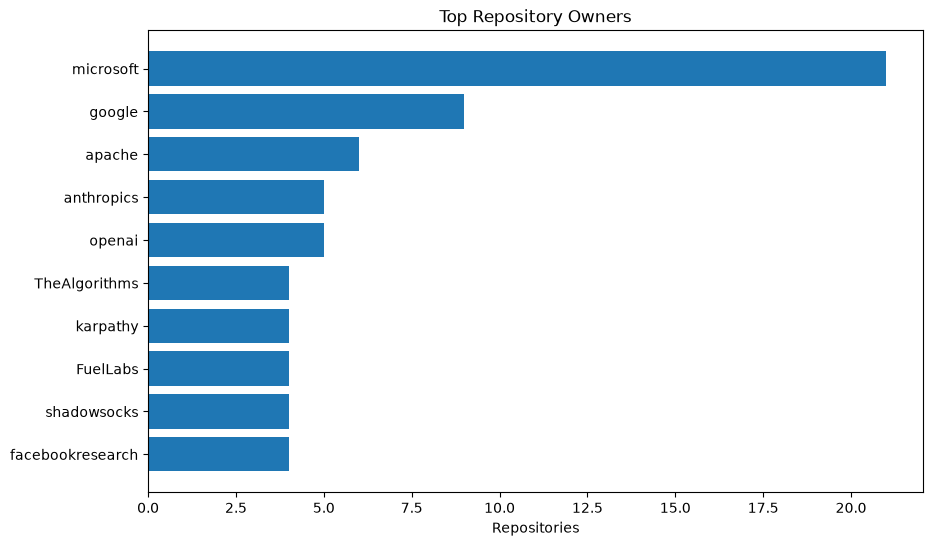

In [14]:
owners = df["owner"].value_counts().head(10) #top 10 repositories owner


plt.figure(figsize=(10,6))
plt.barh(owners.index, owners.values)
plt.title("Top Repository Owners")
plt.xlabel("Repositories")
plt.gca().invert_yaxis()
plt.show()